# CCS cement retrofit NPV simulation

Run the CCS cement retrofit Monte Carlo simulation and visualize the resulting NPV distribution.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_technology_npv,
)


In [2]:
TECHNOLOGY = 'ccs'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_cement_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,electricity_consumption_mwh_per_t,...,bau_variable_opex_eur_per_t,bau_fuel_consumption_mwh_th_per_t,bau_electricity_consumption_mwh_per_t,bau_emissions_tco2_per_t,capex_change_eur_per_t,fixed_opex_change_eur_per_t,variable_opex_change_eur_per_t,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction
0,0,ccs,retrofit,sampled,1000000.0,290.875087,21.328726,5.581270,-0.149100,0.109342,...,5.135369,0.657332,0.084504,0.620035,125.395966,6.390817,0.445901,1.226826,-0.293925,0.923527
1,1,ccs,retrofit,sampled,1000000.0,260.374726,23.723385,5.482188,-0.159191,0.193944,...,5.125930,0.649577,0.093378,0.602551,101.597157,8.776467,0.356257,1.245069,-1.076966,0.884398
2,2,ccs,retrofit,sampled,1000000.0,315.137172,20.598957,6.867771,0.106731,0.304118,...,5.431670,0.697878,0.085678,0.683904,147.965214,6.134707,1.436101,0.847064,-2.549549,0.927767
3,3,ccs,retrofit,sampled,1000000.0,310.136077,19.099132,7.011914,0.458186,0.223054,...,5.260010,0.693428,0.089539,0.634547,146.188717,5.097403,1.751904,0.339245,-1.491146,0.916059
4,4,ccs,retrofit,sampled,1000000.0,293.169913,24.182854,5.653732,0.268744,0.140488,...,5.371749,0.694798,0.084480,0.652753,141.286366,9.463176,0.281983,0.613206,-0.662967,0.909679


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_t = results["npv_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/t"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/t
count,100000.000000,100000.000000
mean,611.537638,24.461506
std,187.086268,7.483451
min,-62.575113,-2.503005
5%,283.789793,11.351592
50%,625.765174,25.030607
95%,886.513247,35.460530
max,1072.139394,42.885576


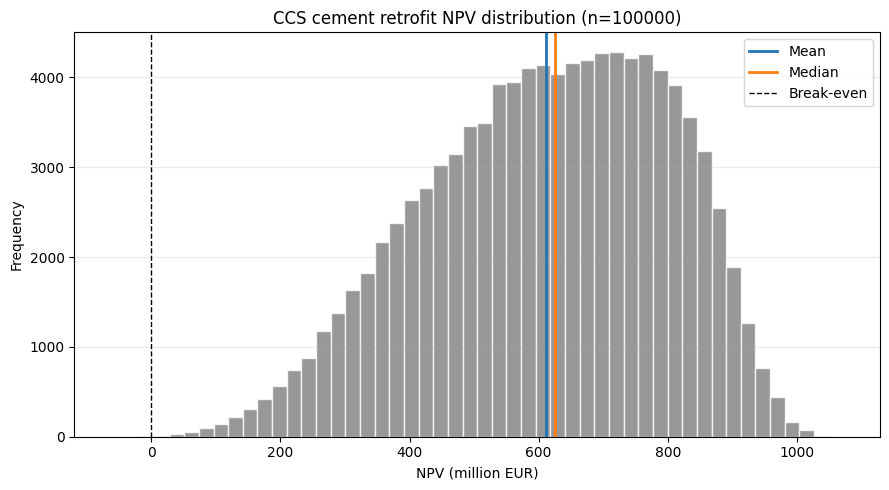

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCS cement retrofit NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


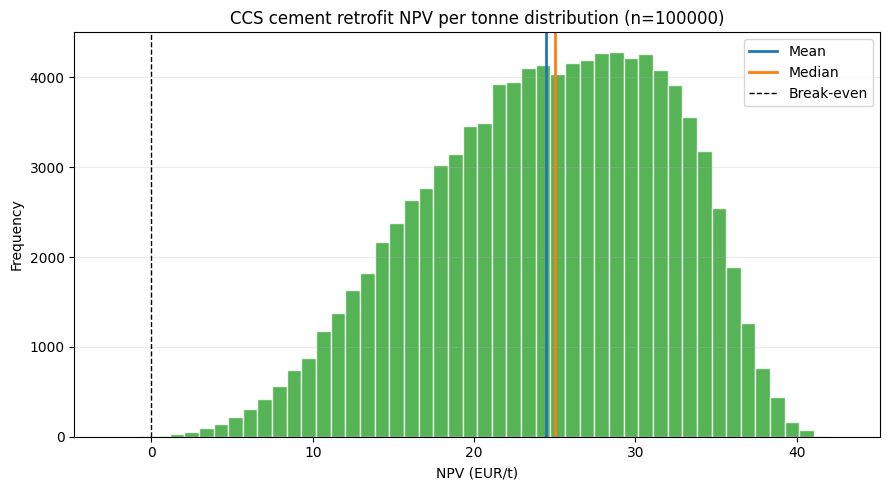

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCS cement retrofit NPV per tonne distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/t)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           21.336836
annual_variable_opex_eur         6.669386
annual_fuel_cost_eur             2.830016
annual_electricity_cost_eur     31.074729
annual_emissions_cost_eur        4.559696
annual_net_cash_flow_eur        83.529338
Name: Mean annual value, million EUR, dtype: float64

In [7]:
retrofit_columns = [
    "capex_change_eur_per_t",
    "fixed_opex_change_eur_per_t",
    "variable_opex_change_eur_per_t",
    "fuel_consumption_reduction_fraction",
    "electricity_consumption_reduction_fraction",
    "emissions_reduction_fraction",
    "bau_capex_eur_per_t",
    "bau_fixed_opex_eur_per_t",
    "bau_variable_opex_eur_per_t",
    "bau_fuel_consumption_mwh_th_per_t",
    "bau_electricity_consumption_mwh_per_t",
    "bau_emissions_tco2_per_t",
]

available_retrofit_columns = [column for column in retrofit_columns if column in results]
retrofit_summary = results[available_retrofit_columns].describe(
    percentiles=[0.05, 0.5, 0.95]
)
retrofit_summary


,capex_change_eur_per_t,fixed_opex_change_eur_per_t,variable_opex_change_eur_per_t,fuel_consumption_reduction_fraction,electricity_consumption_reduction_fraction,emissions_reduction_fraction,bau_capex_eur_per_t,bau_fixed_opex_eur_per_t,bau_variable_opex_eur_per_t,bau_fuel_consumption_mwh_th_per_t,bau_electricity_consumption_mwh_per_t,bau_emissions_tco2_per_t
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,120.106849,7.004427,1.502163,0.649983,-0.953037,0.910012,160.012499,14.332408,5.167223,0.666500,0.086635,0.633377
std,37.480033,1.735347,0.865422,0.375805,0.951554,0.017279,5.770418,0.471200,0.235343,0.040049,0.004713,0.023522
min,55.000619,4.000001,0.000035,0.000025,-2.599977,0.880001,150.000263,13.009529,4.504187,0.610000,0.080000,0.600000
5%,61.594477,4.295981,0.153730,0.064771,-2.433949,0.882995,150.989862,13.451564,4.725440,0.614265,0.080499,0.602579
50%,120.072322,7.007513,1.500257,0.648870,-0.954717,0.909976,160.049191,14.411204,5.207742,0.659535,0.085806,0.629393
95%,178.396722,9.703403,2.851979,1.235149,0.535605,0.936945,169.007981,14.949464,5.474133,0.741932,0.095517,0.677623
max,184.998890,9.999989,2.999947,1.300000,0.699964,0.940000,169.999875,14.999998,5.499993,0.779352,0.099946,0.699866
